# Capstone Project

## Menentukan Pertanyaan Bisnis

* Apa pola alokasi keuangan yang membedakan cluster Rentan, Moderate, dan Aman?
* Fitur apa yang paling berpengaruh terhadap kesehatan finansial seseorang?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Data Wrangling

### Gathering Data

In [ ]:
df=pd.read_csv('/content/data.csv')

In [ ]:
pd.set_option('display.max_columns', None)
df

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,2911.792231,1546.914539,0.000000,831.525120,13.890948,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,1626.143346,1137.351325,1551.723167,564.235007,7.160376,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,3368.457108,2178.515847,3160.026299,628.371220,13.997808,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,5040.249158,2858.194240,6128.550387,4571.118217,0.000000,2526.055712,16.455440,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,1092.689024,1169.095816,1445.215694,515.510300,7.533982,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,40913.466178,51,4,Self_Employed,Tier_1,12274.039853,7703.854895,1646.799940,5477.403246,2084.230191,1945.982149,1210.454952,1641.047762,1938.821782,2841.315106,986.197991,12.353542,1163.318310,1163.318310,597.028412,287.315050,347.658355,145.843671,212.833325,44.900294,98.765527,190.591917
19996,90295.772638,21,1,Student,Tier_2,18059.154528,0.000000,2770.589626,13118.222419,4633.108332,3770.919375,2356.408295,5471.740939,2726.601476,5284.429024,1379.423454,11.754249,10613.589598,30725.175170,3854.823822,359.602765,911.269461,424.064224,1555.548024,129.655981,239.445622,351.436046
19997,40604.567373,30,1,Professional,Tier_2,8120.913475,8089.612716,1548.564328,6018.276121,2493.563674,896.290751,1571.911103,2792.618808,2025.398570,3910.466560,869.046133,13.854837,2267.905134,2267.905134,1385.511100,379.927216,138.209465,297.695658,824.565267,57.891000,72.728663,122.569277
19998,118157.817240,27,2,Professional,Tier_1,35447.345172,12345.910538,4735.672471,16392.438426,8248.242279,2545.419412,4721.792454,9104.612331,5304.363988,6237.319313,2471.016043,17.436659,10603.684814,10603.684814,3217.771594,2265.865033,726.247719,273.912367,859.230004,98.961780,92.189012,569.811212




Dataset tersebut berisi informasi mengenai 20.000 profil demografi, rincian pengeluaran bulanan, target keuangan, serta estimasi potensi penghematan dari pengguna. Untuk detail lebih lanjutnya sebagai berikut.
* Kolom Informasi Income & Demographics:
  * Income: merupakan kolom yang menyimpan informasi mengenai jumlah pendapatan bulanan individu dalam satuan mata uang.
  * Age: merupakan kolom yang menyimpan informasi mengenai usia dari individu tersebut.
  * Dependents: merupakan kolom yang menyimpan informasi mengenai jumlah tanggungan yang ditanggung oleh individu tersebut.
  * Occupation: merupakan kolom yang menyimpan informasi mengenai jenis pekerjaan atau peran jabatan dari individu.
  * City_Tier: merupakan kolom kategori yang menyimpan informasi skala wilayah tempat tinggal individu (misalnya Tier 1, Tier 2, dll).


* Kolom Informasi Monthly Expenses:
  * Kolom-kolom ini mencatat berbagai pengeluaran bulanan individu yang dibagi ke dalam beberapa kategori spesifik, meliputi: Rent (sewa tempat tinggal), Loan_Repayment (pembayaran cicilan/pinjaman), Insurance (premi asuransi), Groceries (belanja bahan makanan), Transport (biaya transportasi), Eating_Out (biaya makan di luar), Entertainment (biaya hiburan), Utilities (biaya tagihan seperti air/listrik), Healthcare (biaya kesehatan), Education (biaya pendidikan), dan Miscellaneous (pengeluaran rupa-rupa/lainnya).


* Kolom Informasi Financial Goals & Savings:
  * Desired_Savings_Percentage: merupakan kolom yang menyimpan informasi mengenai target persentase tabungan bulanan yang ingin dicapai dari total pendapatan.
  * Desired_Savings: merupakan kolom yang menyimpan informasi mengenai nominal target tabungan bulanan dalam bentuk angka/nilai mata uang.
  * Disposable_Income: merupakan kolom yang menyimpan informasi mengenai sisa pendapatan individu setelah dikurangi oleh seluruh total pengeluaran bulanan.


* Kolom Informasi Potential Savings:
  * Kolom-kolom ini berisi estimasi atau perkiraan jumlah uang yang masih dapat dihemat atau dipangkas dari berbagai area pengeluaran variabel individu, yang meliputi kategori: Groceries, Transport, Eating_Out, Entertainment, Utilities, Healthcare, Education, hingga Miscellaneous.

### Asessing Data

**Validasi Tipe Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 non-null  int64  
 3   Occupation                       20000 non-null  object 
 4   City_Tier                        20000 non-null  object 
 5   Rent                             20000 non-null  float64
 6   Loan_Repayment                   20000 non-null  float64
 7   Insurance                        20000 non-null  float64
 8   Groceries                        20000 non-null  float64
 9   Transport                        20000 non-null  float64
 10  Eating_Out                       20000 non-null  float64
 11  Entertainment                    20000 non-null  float64
 12  Utilities         

**Validasi Missing Value**

In [ ]:
df.isnull().sum()

,0
Income,0
Age,0
Dependents,0
Occupation,0
City_Tier,0
Rent,0
Loan_Repayment,0
Insurance,0
Groceries,0
Transport,0


**Validasi Duplikasi Data**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Validasi Inkonsistensi Data**

In [ ]:
expense_cols = [
    'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport',
    'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare',
    'Education', 'Miscellaneous'
]

df['Total_Expenses'] = df[expense_cols].sum(axis=1)

df['Calc_Disposable_Income'] = df['Income'] - df['Total_Expenses']
df['Is_Disposable_Valid'] = np.isclose(df['Disposable_Income'], df['Calc_Disposable_Income'], atol=0.01)

print(f"Jumlah baris dengan Disposable Income salah: {(~df['Is_Disposable_Valid']).sum()}")
df.drop(columns=['Total_Expenses', 'Calc_Disposable_Income', 'Is_Disposable_Valid'], inplace=True)


df['Calc_Desired_Savings'] = df['Income'] * (df['Desired_Savings_Percentage'] / 100)
df['Expected_Desired_Savings'] = np.minimum(df['Calc_Desired_Savings'], np.maximum(0, df['Disposable_Income']))
df['Is_Savings_Valid'] = np.isclose(df['Desired_Savings'], df['Expected_Desired_Savings'], atol=0.01)

print(f"Jumlah baris dengan Desired Savings salah: {(~df['Is_Savings_Valid']).sum()}")
df.drop(columns=['Calc_Desired_Savings', 'Expected_Desired_Savings', 'Is_Savings_Valid'], inplace=True)

categories = ['Groceries', 'Transport', 'Eating_Out', 'Entertainment',
              'Utilities', 'Healthcare', 'Education', 'Miscellaneous']

for cat in categories:
    pot_col = f'Potential_Savings_{cat}'
    invalid_pot = (df[pot_col] > df[cat]).sum()
    if invalid_pot > 0:
        print(f"Peringatan: Ada {invalid_pot} baris di mana potensi hemat {cat} > pengeluaran aslinya!")

Jumlah baris dengan Disposable Income salah: 0
Jumlah baris dengan Desired Savings salah: 0


**Validasi Outlier**

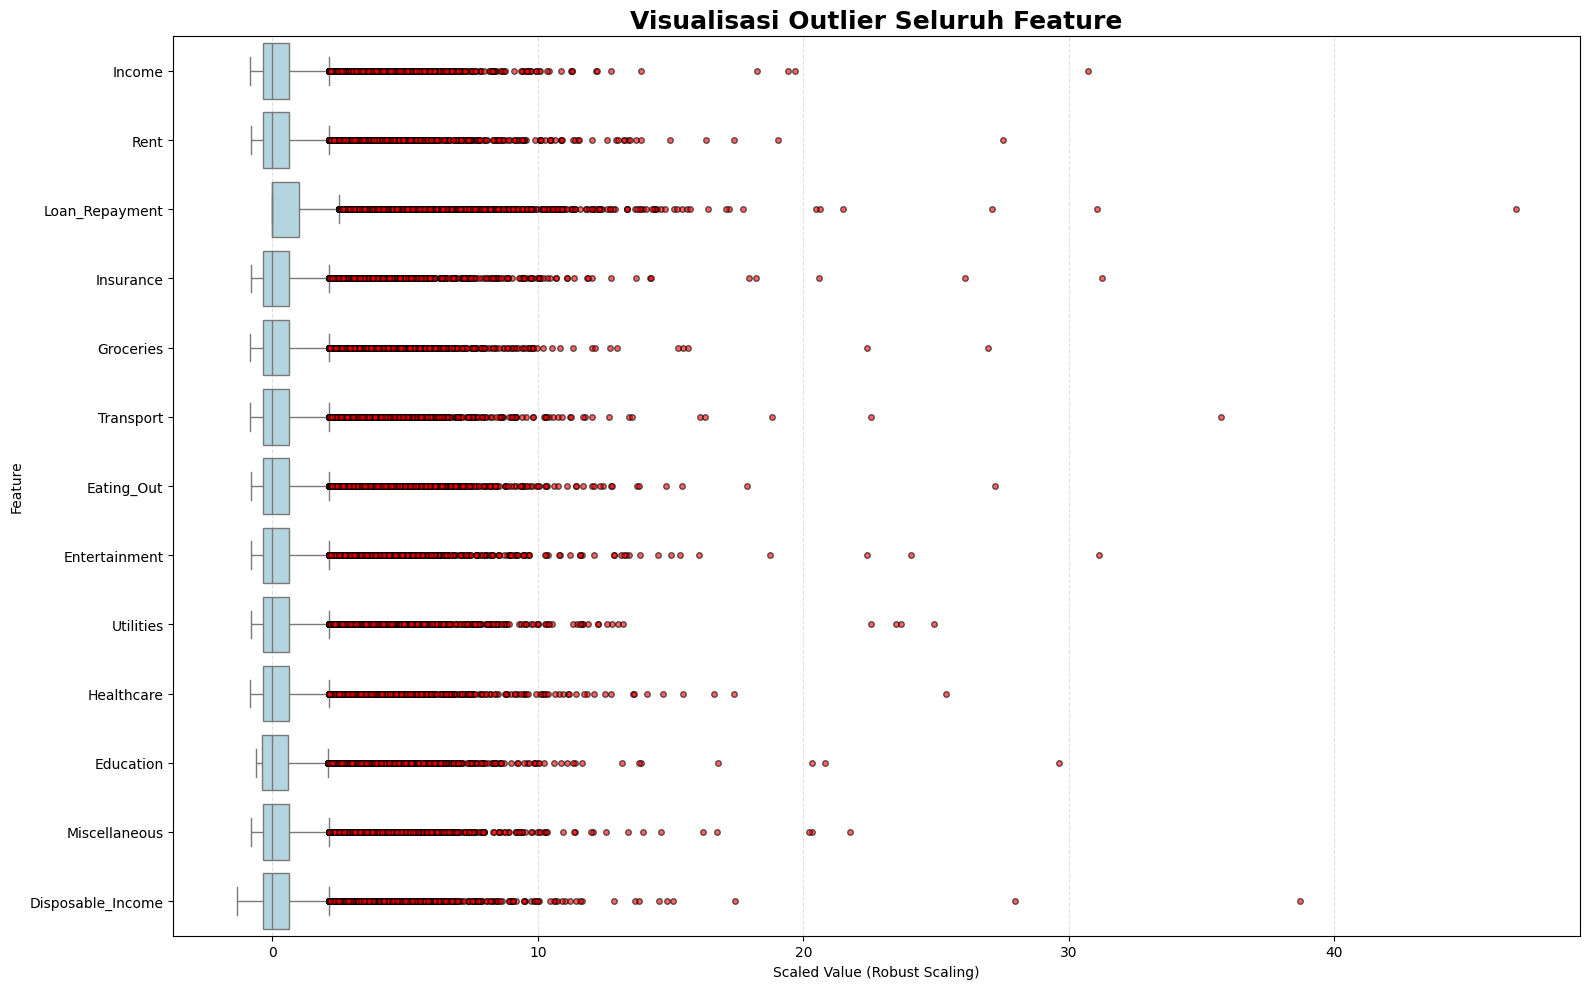

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

cols_to_exclude_from_outlier_handling = [
    'Age',
    'Dependents',
    'Desired_Savings_Percentage',
    'Desired_Savings'
]

potential_savings_cols = [
    col for col in df.columns if 'Potential_Savings' in col
]

cols_to_exclude_from_outlier_handling.extend(
    potential_savings_cols
)

cols_to_check = [
    col for col in numerical_cols
    if col not in cols_to_exclude_from_outlier_handling
]

df_plot = df[cols_to_check].copy()

df_scaled = (
    df_plot - df_plot.median()
) / (df_plot.quantile(0.75) - df_plot.quantile(0.25))

df_melted = df_scaled.melt(
    var_name='Feature',
    value_name='Value'
)

plt.figure(figsize=(16, 10))

sns.boxplot(
    data=df_melted,
    x='Value',
    y='Feature',
    color='lightblue',
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=4,
        alpha=0.6
    )
)

plt.title(
    'Visualisasi Outlier Seluruh Feature',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Scaled Value (Robust Scaling)')
plt.ylabel('Feature')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Pada proses Validasi outlier, variabel Desired Savings, Desired Savings Percentage, seluruh feature Potential Savings, serta variabel Age dan Dependents tidak disertakan dalam analisis. Hal ini dilakukan karena penelitian berfokus pada pola pengeluaran (expense behavior) sehingga proses deteksi outlier hanya diterapkan pada variabel pengeluaran yang relevan. Selain itu, apabila seluruh variabel disertakan dalam proses handling outlier, dikhawatirkan jumlah data yang tereliminasi menjadi terlalu banyak dan dapat memengaruhi kualitas serta representativitas dataset yang digunakan.

### Cleaning Data

In [ ]:
def get_outlier_indices(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_idx = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)].index
    return outlier_idx

outlier_indices = set()

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

cols_to_exclude_from_outlier_handling = [
    'Age', 'Dependents', 'Desired_Savings_Percentage', 'Desired_Savings'
]
potential_savings_cols = [col for col in df.columns if 'Potential_Savings' in col]
cols_to_exclude_from_outlier_handling.extend(potential_savings_cols)

kolom_kunci = [col for col in numerical_cols if col not in cols_to_exclude_from_outlier_handling]

for col in kolom_kunci:
    indices = get_outlier_indices(df, col)
    outlier_indices.update(indices)

df_clean = df.drop(index=list(outlier_indices)).reset_index(drop=True)

print(f"Data awal: {len(df)} baris")
print(f"Data bersih: {len(df_clean)} baris")
print(f"Data dibuang: {len(df) - len(df_clean)} baris")

Data awal: 20000 baris
Data bersih: 16432 baris
Data dibuang: 3568 baris


Kemudian, proses handling outlier dilakukan dengan metode penghapusan data outlier. Pendekatan ini dipilih karena penggunaan metode capping dikhawatirkan dapat memengaruhi distribusi dan hubungan antar feature, sehingga berpotensi menyebabkan data menjadi kurang representatif dan mengurangi validitas analisis yang dilakukan. Sehingga sebanyak 3568 data dihapus dari data awal yang menyisakan hanya 16432 data.

## Explaratory Data Analysis

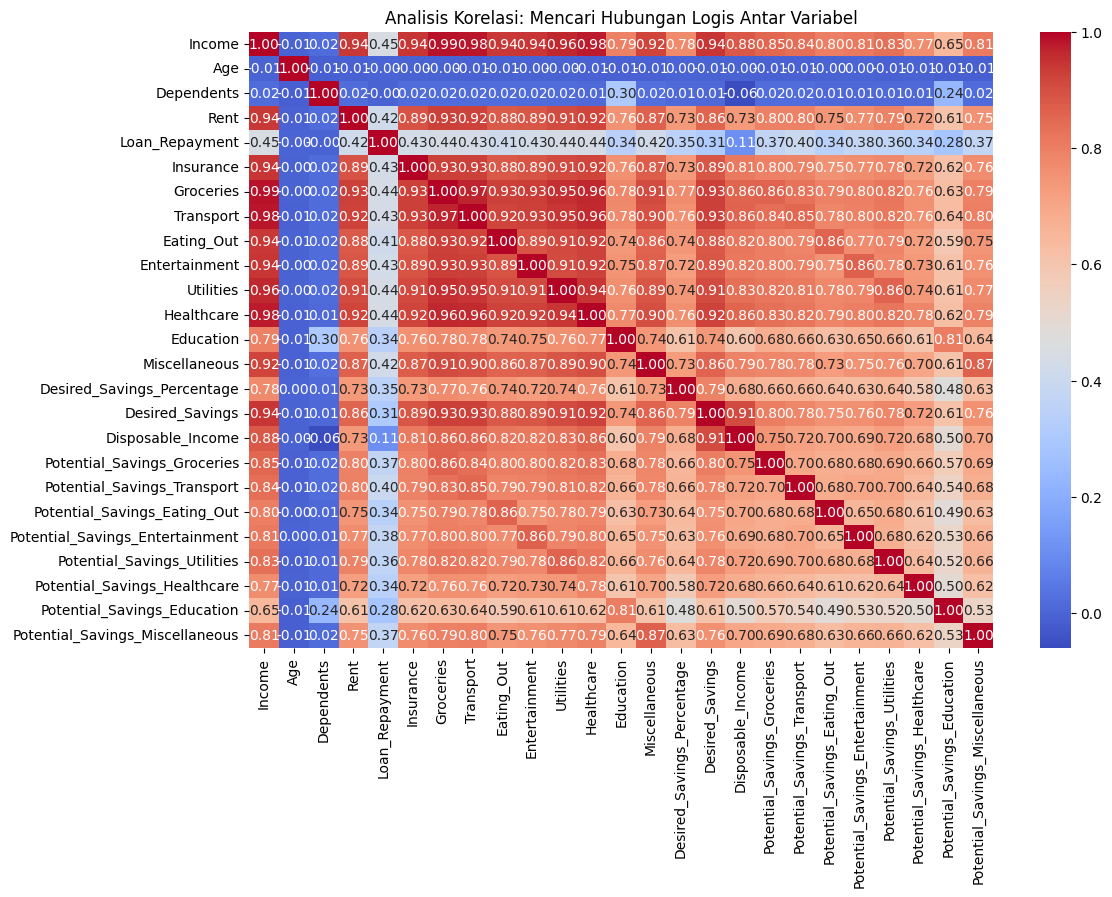

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Analisis Korelasi: Mencari Hubungan Logis Antar Variabel")
plt.show()

Dari heatmap tersebut dapat disimpulkan sebagai berikut.
1. Pendapatan (**Income**) Menjadi Penggerak Utama Pengeluaran & Tabungan Variabel **Income** memiliki korelasi positif yang sangat kuat (berkisar antara 0.78 hingga 0.98, berwarna merah tua) dengan hampir semua kategori pengeluaran seperti **Rent** (0.94), **Groceries** (0.94), **Transport** (0.98), **Healthcare** (0.98), serta variabel tabungan seperti **Desired_Savings** (0.94) dan **Disposable_Income** (0.88).

   - Kesimpulan: Pola ini sangat logis; semakin tinggi pendapatan seseorang, semakin besar pula nominal yang mereka habiskan untuk berbagai kebutuhan hidup, fasilitas, sekaligus jumlah yang dapat mereka tabung.

2. Usia (**Age**) dan Jumlah Tanggungan (**Dependents**) Tidak Memiliki Hubungan Linear Kolom dan baris untuk variabel **Age** dan **Dependents** hampir seluruhnya berwarna biru dengan nilai korelasi yang sangat mendekati nol (berkisar antara -0.02 hingga 0.02).

   - Kesimpulan: Dalam dataset ini, faktor usia atau banyaknya tanggungan tidak memengaruhi secara linear seberapa besar pendapatan seseorang, ke mana mereka membelanjakan uangnya, atau berapa banyak yang mereka tabung.

3. Korelasi Unik pada Pelunasan Pinjaman (**Loan_Repayment**) Variabel **Loan_Repayment** menunjukkan korelasi negatif dengan tingkat pendapatan (**Income**) sebesar -0.45.

    - Kesimpulan: Hal ini mengindikasikan bahwa kelompok dalam data yang memiliki pendapatan lebih tinggi cenderung memiliki beban pelunasan pinjaman yang lebih rendah, atau sebaliknya. Hubungan **Loan_Repayment** dengan variabel pengeluaran lainnya juga cenderung lemah atau negatif.

4. Konsistensi Pengeluaran Antar-Kategori. Berbagai kategori pengeluaran seperti **Groceries**, **Transport**, **Eating_Out**, **Entertainment**, dan **Utilities** memiliki korelasi yang sangat tinggi satu sama lain (sebagian besar di atas 0.90).

   - Kesimpulan: Ini menunjukkan tren gaya hidup yang selaras; seseorang yang memiliki pengeluaran tinggi di satu sektor (misalnya transportasi atau makanan) cenderung memiliki pengeluaran yang tinggi pula di sektor lainnya, karena didorong oleh daya beli (**Income**) yang tinggi.

In [ ]:
df_clean

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,2911.792231,1546.914539,0.000000,831.525120,13.890948,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,1626.143346,1137.351325,1551.723167,564.235007,7.160376,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,3368.457108,2178.515847,3160.026299,628.371220,13.997808,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,1092.689024,1169.095816,1445.215694,515.510300,7.533982,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076
4,24875.610267,57,4,Self_Employed,Tier_2,4975.122053,0.000000,1038.230996,3250.067756,1760.164812,1049.067453,751.016815,1024.309765,1022.295439,2003.852035,402.217843,5.944242,1478.666359,7599.265300,957.619116,521.683848,135.925865,148.952326,86.567256,13.143683,33.961843,96.675925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16427,80438.330877,62,4,Professional,Tier_2,16087.666175,0.000000,3479.926153,11548.313022,4071.920735,2984.814667,3352.738729,3718.203112,2612.874648,6545.774466,1123.583717,11.098568,8927.503229,24912.515454,1034.481775,696.042581,208.439153,596.488748,1109.045927,19.906816,186.232480,175.507987
16428,20620.154558,61,1,Retired,Tier_3,3093.023184,0.000000,821.294906,2159.381989,1275.250459,1005.009800,896.750441,972.247753,787.249156,1741.331915,422.179699,5.544650,1143.315464,7446.435256,612.271344,364.612799,157.925834,211.000447,264.635419,9.133864,66.936521,64.559517
16429,61085.128305,64,4,Student,Tier_2,12217.025661,0.000000,2963.084540,8560.107726,3910.755681,3039.564584,2430.394638,2874.961586,2975.925376,4604.035319,743.463356,10.514527,6422.812078,16765.809839,1796.715822,329.180500,626.170619,634.469609,547.171345,145.374520,67.819865,112.041740
16430,64281.365782,50,1,Self_Employed,Tier_1,19284.409734,0.000000,1951.361941,9483.413926,5000.588006,1389.118928,2855.774060,3224.050511,2725.260184,3450.488957,1385.982196,12.932447,8313.153809,13530.917337,1515.836546,1080.900911,291.388648,541.731784,449.781783,65.484906,145.847265,96.928171


## Feature Engineering and Selection

### Feature Selection

In [ ]:
kolom_hapus = ['Occupation', 'Age', 'Dependents','City_Tier','Desired_Savings_Percentage', 'Desired_Savings']
kolom_potential = [col for col in df.columns if 'Potential' in col]
total_kolom_dihapus = kolom_hapus + kolom_potential

df_clean.drop(columns=total_kolom_dihapus, inplace=True)

Feature **Age**, **Occupation**, **City_Tier**, dan **Dependents** dihapus karena tidak menunjukkan korelasi yang signifikan terhadap feature lainnya yang digunakan dalam analisis. Selain itu, ditemukan beberapa anomali pada data, seperti individu berusia 64 tahun dengan jumlah dependents sebanyak 4 namun memiliki pekerjaan sebagai student. Kondisi tersebut dinilai tidak realistis dan berpotensi memengaruhi kualitas analisis, sehingga feature-feature tersebut tidak digunakan dalam penelitian ini.

Selain itu, feature **Desired_Savings_Percentage**, **Desired_Savings**, serta seluruh feature **Potential_Savings** juga dihapus karena tidak digunakan dalam proses analisis lanjutan. Penelitian ini berfokus pada analisis pola pengeluaran, sehingga hanya feature yang berkaitan dengan pengeluaran yang dipertahankan.

### Standarisasi

In [ ]:
kategori_pengeluaran = ['Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
                        'Transport', 'Eating_Out', 'Entertainment',
                        'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Disposable_Income']

for col in kategori_pengeluaran:
    df_clean[f'{col}_Ratio'] = df_clean[col] / (df_clean['Income'] + 1)

df_clean.drop(columns=kategori_pengeluaran, inplace=True)

if 'Disposable_Income_Ratio' in df_clean.columns:
    df_clean.rename(columns={'Disposable_Income_Ratio': 'Savings_Ratio'}, inplace=True)

df_clean = df_clean.drop(columns=['Income'])

Karena dataset ini menggunakan satuan mata uang INR, maka perlu dilakukan proses standarisasi agar data dapat digunakan dan dibandingkan pada dataset dengan mata uang lainnya. Oleh karena itu, seluruh feature pengeluaran akan dibagi dengan nilai Income sehingga setiap feature direpresentasikan dalam bentuk rasio terhadap pendapatan.

In [ ]:
df_clean

,Rent_Ratio,Loan_Repayment_Ratio,Insurance_Ratio,Groceries_Ratio,Transport_Ratio,Eating_Out_Ratio,Entertainment_Ratio,Utilities_Ratio,Healthcare_Ratio,Education_Ratio,Miscellaneous_Ratio,Savings_Ratio
0,0.299993,0.000000,0.049430,0.149172,0.059074,0.037004,0.034414,0.065231,0.034654,0.000000,0.018628,0.252376
1,0.199993,0.000000,0.032373,0.104932,0.057448,0.024177,0.039101,0.060542,0.042344,0.057772,0.021007,0.360274
2,0.149997,0.091567,0.043714,0.125340,0.063956,0.030055,0.034214,0.066876,0.043251,0.062738,0.012475,0.275796
3,0.199992,0.125124,0.025563,0.121977,0.051300,0.027851,0.026539,0.043925,0.046996,0.058096,0.020723,0.251874
4,0.199992,0.000000,0.041735,0.130648,0.070756,0.042171,0.030190,0.041176,0.041095,0.080552,0.016169,0.305478
...,...,...,...,...,...,...,...,...,...,...,...,...
16427,0.199998,0.000000,0.043262,0.143566,0.050621,0.037106,0.041680,0.046224,0.032483,0.081375,0.013968,0.309706
16428,0.149993,0.000000,0.039828,0.104717,0.061842,0.048737,0.043487,0.047148,0.038177,0.084444,0.020473,0.361107
16429,0.199997,0.000000,0.048507,0.140132,0.064020,0.049759,0.039786,0.047064,0.048717,0.075370,0.012171,0.274462
16430,0.299995,0.000000,0.030356,0.147527,0.077791,0.021610,0.044425,0.050155,0.042395,0.053677,0.021561,0.210492


### Menentukan target dengan cara Feature Engineering

Karena label tidak tersedia di dataset mentah, maka dilakukan pembuatan label target yang memanfaatkan pengetahuan domain untuk mendefinisikan kelas secara eksplisit melalui aturan logis. Hal ini umumnya digunakan dalam skenario, di mana label ground truth tidak tersedia dalam dataset mentah, tetapi kriteria klasifikasi dapat diturunkan dari teori atau standar yang sudah diakui (Ratner et al., 2020). Kemudian penentuan target berdasarkan penggunaan savings ratio sebagai basis klasifikasi sangat sesuai. Hal ini didukung oleh literatur, yaitu kecukupan tabungan secara mandiri adalah indikator ketahanan finansial yang baik. (McKnight & Rucci, 2020). Selanjutnya mengapa menggunakan treshold 10% dan 20% sendiri merupakan penyederhanaan dari penelitian yang dilakukan oleh Hamid et al. (2023) yang menggunakan rasio tabungan terhadap pendapatan untuk mengelompokkan individu ke dalam beberapa rentang **Savings_Ratio**, yaitu kurang dari 5%, 5-10%, 10-20%, 20-35%, 35-50%, dan lebih dari 50%.

Sehingga pada penelitian ini hanya mengelompokkan individu berdasarkan 3 kelompok yakni:
- **Savings_Ratio** di bawah 10% akan dikategorikan sebagai Rentan.
- **Savings_Ratio** di atas 10% hingga 20% dikategorikan sebagai Moderate.
- **Savings_Ratio** di atas 20% akan dikategorikan sebagai Sehat.

In [ ]:
kondisi = [
    df_clean['Savings_Ratio'] < 0.1,
    df_clean['Savings_Ratio'] <= 0.2,
    df_clean['Savings_Ratio'] > 0.2
]

pilihan = [0, 1, 2]
df_clean['Financial_Status'] = np.select(kondisi, pilihan)

print("--- JUMLAH BARIS TIAP KELAS ---")
print(df_clean['Financial_Status'].value_counts().sort_index())

print("\n--- PERSENTASE DISTRIBUSI (%) ---")
print(df_clean['Financial_Status'].value_counts(normalize=True).sort_index() * 100)

--- JUMLAH BARIS TIAP KELAS ---
Financial_Status
0      929
1     3338
2    12165
Name: count, dtype: int64

--- PERSENTASE DISTRIBUSI (%) ---
Financial_Status
0     5.653603
1    20.314021
2    74.032376
Name: proportion, dtype: float64


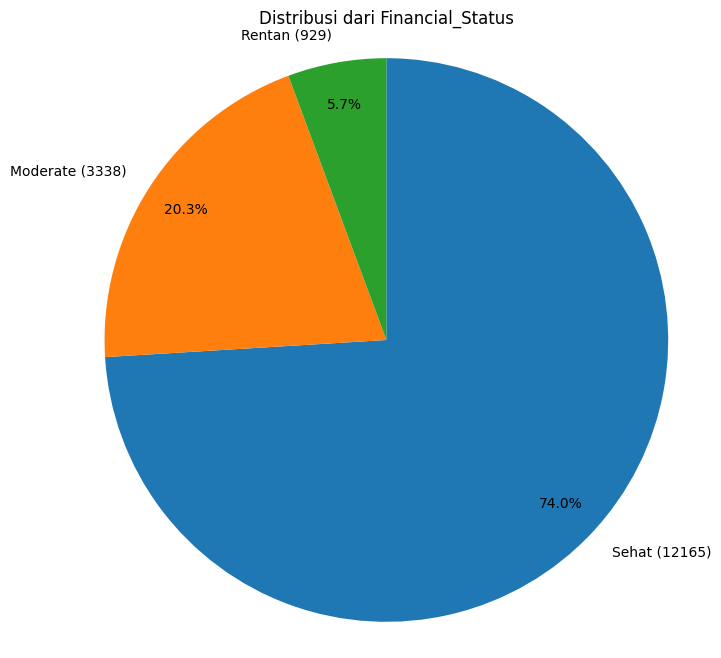

In [ ]:
status_counts = df_clean['Financial_Status'].value_counts()
status_percentages = df_clean['Financial_Status'].value_counts(normalize=True) * 100

Financial_Status_labels = {
    0: 'Rentan',
    1: 'Moderate',
    2: 'Sehat',
}

labels = [f'{Financial_Status_labels[idx]} ({count})' for idx, count in status_counts.items()]

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=labels, autopct=lambda p: f'{p:.1f}%' if p > 0 else '', startangle=90, counterclock=False, pctdistance=0.85)
plt.title('Distribusi dari Financial_Status')
plt.axis('equal')
plt.show()

Setelah dilakukan proses feature engineering, ditemukan adanya ketimpangan (class imbalance) distribusi yang cukup signifikan. Kategori Sehat (Kelas 2) mendominasi persebaran data dengan 74.03%, diikuti oleh kategori Moderate (Kelas 1) sebesar 20.16%, dan kategori Rentan (Kelas 0) di posisi terakhir dengan 5.61%. Secara keseluruhan, angka ini mencerminkan kondisi kesehatan finansial yang sangat positif dalam dataset, di mana mayoritas individu berada di zona aman dan proporsi kelompok yang rentan tergolong sangat minim.

## Visualization & Explanatory Analysis

**1. Apa pola alokasi keuangan yang membedakan cluster Rentan, Moderate, dan Aman?**

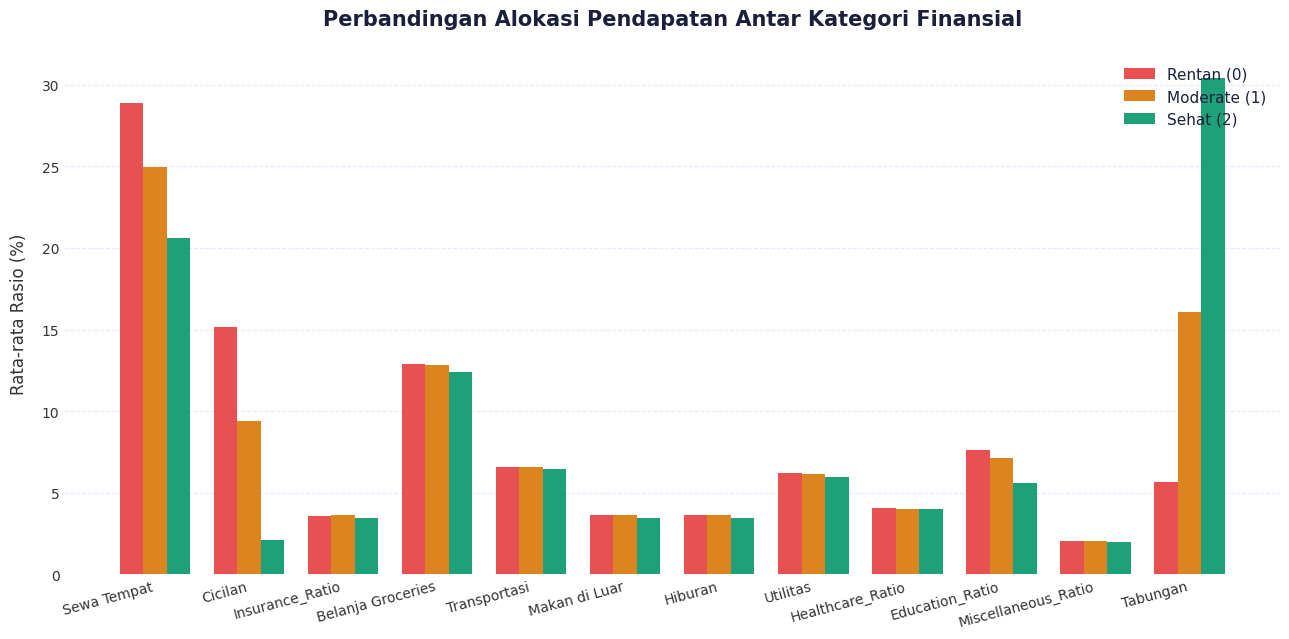

In [ ]:
columns_to_plot = [c for c in df_clean.columns if c.endswith("_Ratio")]

mean_kategori = (
    df_clean.groupby("Financial_Status")[columns_to_plot].mean() * 100
)

label_mapping = {
    "Savings_Ratio": "Tabungan",
    "Rent_Ratio": "Sewa Tempat",
    "Loan_Repayment_Ratio": "Cicilan",
    "Groceries_Ratio": "Belanja Groceries",
    "Transport_Ratio": "Transportasi",
    "Eating_Out_Ratio": "Makan di Luar",
    "Entertainment_Ratio": "Hiburan",
    "Utilities_Ratio": "Utilitas",
}
nice_labels = [label_mapping.get(col, col) for col in columns_to_plot]

x = np.arange(len(nice_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

ax.bar(
    x - width,
    mean_kategori.loc[0],
    width,
    label="Rentan (0)",
    color="#E53E3E",
    alpha=0.9,
    zorder=3,
)
ax.bar(
    x,
    mean_kategori.loc[1],
    width,
    label="Moderate (1)",
    color="#D97706",
    alpha=0.9,
    zorder=3,
)
ax.bar(
    x + width,
    mean_kategori.loc[2],
    width,
    label="Sehat (2)",
    color="#059669",
    alpha=0.9,
    zorder=3,
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(
    nice_labels, rotation=15, ha="right", color="#333333", fontsize=11
)
ax.set_ylabel("Rata-rata Rasio (%)", color="#333333", fontsize=12, labelpad=10)
ax.tick_params(colors="#333333", labelsize=10, length=0)

ax.grid(alpha=0.15, linestyle="--", color="#4C78FF", axis="y", zorder=0)

ax.set_title(
    "Perbandingan Alokasi Pendapatan Antar Kategori Finansial",
    fontsize=15,
    fontweight="bold",
    color="#1A1F3C",
    pad=20,
)
legend = ax.legend(frameon=False, fontsize=11, loc="upper right")
for text in legend.get_texts():
    text.set_color("#1A1F3C")

plt.tight_layout()
plt.show()

Berdasarkan visualisasi di atas, terdapat perbedaan pola alokasi pendapatan yang sangat kontras di antara ketiga kategori finansial, terutama pada aspek beban biaya tetap (fixed costs) dan kemampuan menabung:

- Kategori Rentan: Memiliki kapasitas menabung yang sangat kritis, di mana mereka hanya mampu menyisihkan rata-rata 5.5% dari pendapatan. Hal ini merupakan dampak langsung dari fixed-cost trap, yaitu tingginya beban biaya tetap untuk sewa tempat tinggal (rata-rata 29%) dan cicilan (rata-rata 15%). Akibatnya, kelompok ini memiliki ruang finansial yang sangat sempit dan rentan jika menghadapi pengeluaran darurat.

- Kategori Moderate: Menunjukkan kondisi finansial yang relatif lebih aman dengan rata-rata savings rate sebesar 16%. Kelompok ini sudah mampu mengamankan batas minimum investasi masa depan sekaligus memenuhi kebutuhan rutin, meskipun ruang gerak mereka masih sedikit tertahan oleh sisa beban cicilan (rata-rata 9.5%) dan sewa tempat tinggal (rata-rata 25%).

- Kategori Sehat: Menunjukkan tingkat kesehatan finansial yang paling ideal dengan kemampuan menyisihkan rata-rata 30.5% pendapatan untuk tabungan atau investasi. Kunci utama dari kesehatan finansial kelompok ini adalah keberhasilan mereka dalam menekan beban cicilan hingga titik minimal (rata-rata 2%) serta rasio sewa yang lebih rendah (rata-rata 20.5%), sehingga memberikan fleksibilitas arus kas yang sangat longgar.

Menariknya, rasio pengeluaran untuk kategori lainnya cenderung hampir serupa di antara ketiga kelompok tersebut. Hal ini menandakan bahwa faktor pembeda utama sekaligus beban finansial terberat yang memengaruhi kesehatan keuangan setiap kategori adalah biaya sewa tempat tinggal serta beban cicilan.

**2. Fitur apa yang paling berpengaruh terhadap klasifikasi kesehatan finansial?**

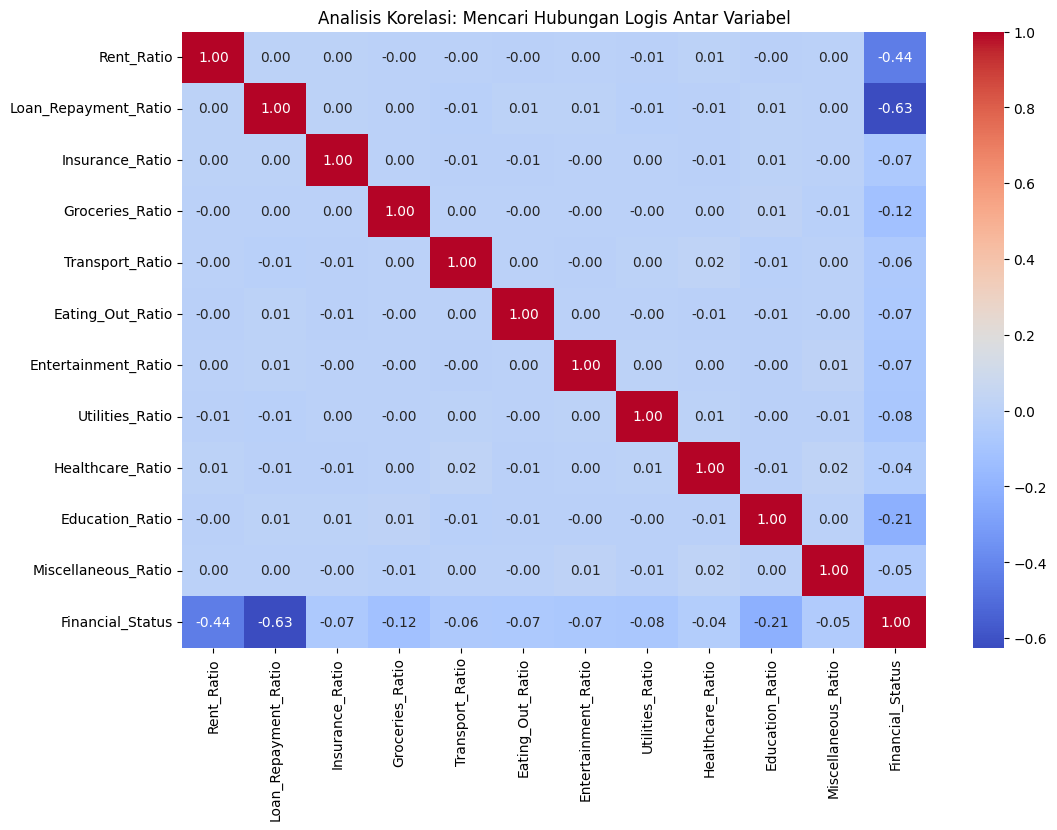

In [ ]:
corr_cols = [
    c
    for c in df_clean.columns
    if c.endswith("_Ratio") and c != "Savings_Ratio"
] + ["Financial_Status"]

plt.figure(figsize=(12, 8))

corr_matrix = df_clean[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Analisis Korelasi: Mencari Hubungan Logis Antar Variabel")
plt.show()

Fitur **Savings_Ratio** sengaja dikecualikan dari analisis korelasi ini karena variabel tersebut digunakan secara langsung untuk membangun target **Financial_Status**, sehingga berpotensi menyebabkan redundansi data. Jika ditinjau dari heatmap di atas, terlihat bahwa seluruh kategori pengeluaran memiliki korelasi negatif terhadap status finansial seseorang. Di antara seluruh variabel tersebut, **Loan_Repayment_Ratio** (-0.63) dan **Rent_Ratio** (-0.44) menunjukkan nilai korelasi negatif tertinggi. Hasil ini memvalidasi analisis pola alokasi keuangan sebelumnya, yang membuktikan secara empiris bahwa tingginya beban cicilan dan biaya sewa tempat tinggal merupakan faktor penentu utama yang menekan tingkat kesehatan finansial individu ke kategori Moderate maupun Rentan.

## Data Splitting

In [ ]:
df_clean.drop(columns=['Savings_Ratio'], inplace=True)

Sebelum dilakukan data splitting kolom **Savings_Ratio** harus dihapus agar tidak terjadi data leakage. Karena kolom **Savings_Ratio** saja yang digunakan untuk membangun target.

In [ ]:
X = df_clean.drop(columns=['Financial_Status'])
y = df_clean['Financial_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"Total baris awal  : {len(df_clean)}")
print(f"Dimensi X_train   : {X_train.shape} (80%)")
print(f"Dimensi X_test    : {X_test.shape} (20%)")

print("\n--- Distribusi Kelas di y_train (%) ---")
print(y_train.value_counts(normalize=True) * 100)

print("\n--- Distribusi Kelas di y_test (%) ---")
print(y_test.value_counts(normalize=True) * 100)

Total baris awal  : 16432
Dimensi X_train   : (13145, 11) (80%)
Dimensi X_test    : (3287, 11) (20%)

--- Distribusi Kelas di y_train (%) ---
Financial_Status
2    74.035755
1    20.311906
0     5.652339
Name: proportion, dtype: float64

--- Distribusi Kelas di y_test (%) ---
Financial_Status
2    74.018862
1    20.322483
0     5.658655
Name: proportion, dtype: float64


Selanjutnya, dilakukan pembagian data (data splitting) dengan rasio 80:20 serta menerapkan stratifikasi (stratify=y) untuk menjaga konsistensi distribusi kelas, baik pada data latih (train) maupun data uji (test).

In [ ]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [ ]:
df_train

,Rent_Ratio,Loan_Repayment_Ratio,Insurance_Ratio,Groceries_Ratio,Transport_Ratio,Eating_Out_Ratio,Entertainment_Ratio,Utilities_Ratio,Healthcare_Ratio,Education_Ratio,Miscellaneous_Ratio,Financial_Status
11234,0.199996,0.000000,0.033148,0.127548,0.071954,0.028064,0.025272,0.048973,0.041154,0.082061,0.020359,2
15688,0.299991,0.175284,0.044565,0.103460,0.064876,0.049311,0.022062,0.052077,0.043512,0.051520,0.016838,0
5138,0.299985,0.000000,0.026164,0.136188,0.066405,0.047792,0.036547,0.071406,0.036222,0.094980,0.018015,1
8296,0.199997,0.000000,0.026432,0.119351,0.079002,0.044492,0.042480,0.058110,0.041275,0.065296,0.015924,2
7695,0.199994,0.000000,0.037959,0.132669,0.066743,0.022856,0.025168,0.059095,0.043983,0.089742,0.011087,2
...,...,...,...,...,...,...,...,...,...,...,...,...
15507,0.299985,0.000000,0.022550,0.136205,0.060279,0.025749,0.040301,0.066465,0.034947,0.056350,0.010809,2
4104,0.149995,0.139435,0.025635,0.141628,0.069507,0.035286,0.038684,0.060041,0.042005,0.088442,0.011437,1
5145,0.299990,0.070290,0.021508,0.137962,0.066708,0.026899,0.041587,0.076712,0.042706,0.058363,0.020842,1
6838,0.199989,0.000000,0.036086,0.146537,0.076736,0.037167,0.044642,0.066470,0.043933,0.090822,0.027241,2


In [ ]:
df_train.to_csv('df_train2.csv', index=False)

In [ ]:
df_test.to_csv('df_test2.csv', index=False)

# Kesimpulan

Berdasarkan hasil analisis yang telah dilakukan, dapat disimpulkan bahwa mayoritas individu pada dataset memiliki kondisi kesehatan finansial yang relatif baik. Hal ini ditunjukkan oleh distribusi kategori finansial yang ada:

  - **Kelas Sehat**: 74,03% (Sangat Dominan)

  - **Kelas Moderate**: 20,16%

  - **Kelas Rentan**: 5,61%

Distribusi tersebut mengindikasikan bahwa sebagian besar individu telah memiliki kemampuan pengelolaan keuangan yang cukup baik, khususnya dalam menjaga proporsi tabungan terhadap pendapatan.

Hasil analisis juga menunjukkan bahwa pengeluaran yang paling berpengaruh terhadap kondisi finansial berasal dari kategori fixed expenses (biaya tetap), terutama pada komponen:

  - **Loan_Repayment** (Cicilan)

  - **Rent** (Sewa Tempat Tinggal)

Tingginya proporsi pengeluaran pada kedua komponen tersebut secara signifikan dapat mengurangi kapasitas individu dalam menabung dan meningkatkan risiko kerentanan finansial.

Untuk memperbaiki struktur keuangan, diperlukan langkah-langkah strategis sebagai berikut:

- Bijak Mengelola Pinjaman: Membangun kesadaran finansial dalam mengelola kewajiban pinjaman secara lebih bijak, khususnya dengan menghindari pinjaman yang bersifat konsumtif dan tidak mendesak.

- Efisiensi Biaya Hunian: Pemilihan tempat tinggal dengan biaya sewa yang lebih terjangkau dapat menjadi strategi efektif untuk menekan pengeluaran rutin, sehingga memberikan ruang finansial yang lebih besar untuk tabungan maupun kebutuhan darurat.

Dengan pengelolaan pengeluaran yang lebih optimal, mobilitas kelas finansial dapat tercapai:

- Individu pada kategori Moderate berpotensi meningkatkan kondisi finansialnya menjadi kategori Sehat.

- Individu pada kategori Rentan dapat secara bertahap mencapai kondisi finansial yang lebih Stabil.

Upaya intervensi pada biaya tetap ini sangat penting untuk meningkatkan ketahanan finansial jangka panjang dan mengurangi risiko terjadinya permasalahan ekonomi antargenerasi (intergenerational poverty).